# Exploring Pointing

This notebook is adapted from the toast tutorial. It is meant to explore how toast currently handles pointing

In [7]:
# Optionally change logging level
import os
os.environ["TOAST_LOGLEVEL"] = "INFO"
# This is needed before importing toast, and should
# match the value passed to the '-t' option of %toast
os.environ["OMP_NUM_THREADS"] = "4"

# TOAST interactive startup
import toast.interactive
%load_ext toast.interactive

%toast -p 1 -t 4 -a

The toast.interactive extension is already loaded. To reload it, use:
  %reload_ext toast.interactive
TOAST INFO: Using 1 processes with 4 threads each.


In [8]:
# Built-in modules
import sys
import os
import re
import datetime
import shutil

# External modules
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import astropy.units as u
from astropy.table import Row, QTable
import healpy as hp

# TOAST
import toast
import toast.schedule_sim_ground
from toast.instrument_sim import plot_focalplane
from toast.tests import helpers
from toast.observation import default_values as defaults

# Display inline plots
%matplotlib inline
from IPython.display import Image
from IPython.display import display

In [9]:
# MPI communicator
world, procs, rank = toast.mpi.get_world()
comm = helpers.create_comm(world, single_group=True)

In [10]:
# Output directory for this tutorial
topdir = "out_sim_ground"
if rank == 0 and os.path.exists(topdir):
    shutil.rmtree(topdir)
out_dir = helpers.create_outdir(world, topdir=topdir)

# Fake Telescope

We create just a small number of detectors here since we are running this notebook serially. If you use more processes you can increase the number of detectors on the focalplane. First create a `Site` for telescope:

In [11]:
site = toast.instrument.GroundSite("atacama", "-22:57:30", "-67:47:10", 5200.0 * u.meter)

Now we will create a focalplane consisting of three rhombus wafers packed into a hexagon.

In [20]:
fp_fwhm = 30.0 * u.arcmin

focalplane = toast.instrument_sim.fake_rhombihex_focalplane(
    n_pix_rhombus=4,
    width=8.0 * u.degree,
    gap=0 * u.radian,
    sample_rate=10.0 * u.Hz,
    epsilon=0.0,
    fwhm=fp_fwhm,
    bandcenter=150 * u.GHz,
    bandwidth=20 * u.GHz,
    psd_net=300.0 * u.uK * np.sqrt(1 * u.second),
    psd_fmin=1.0e-5 * u.Hz,
    psd_alpha=1.0,
    psd_fknee=0.05 * u.Hz,
    fwhm_sigma=0.0 * u.arcmin,
    bandcenter_sigma=0 * u.GHz,
    bandwidth_sigma=0 * u.GHz,
    random_seed=123456,
)
fov = focalplane.field_of_view

In [21]:
# Look at the table of detector properties
focalplane.detector_data[:2]

name,quat,pol_leakage,psi_pol,gamma,fwhm,psd_fmin,psd_fknee,psd_alpha,psd_net,bandcenter,bandwidth,pixel,uid,pol_angle,pol_efficiency
,,,rad,rad,arcmin,Hz,Hz,,K s(1/2),GHz,GHz,,,rad,
str8,float64[4],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str3,uint32,float64,float64
D00A-150,0.033349436796739546 .. 0.7931215574154822,0.0,0.0,1.8303167109061045,30.0,1e-05,0.05,1.0,0.0003,150.0,20.0,D00,13695585,1.3067179353078051,1.0
D00B-150,-0.0010778343549474947 .. 0.13150249993391128,0.0,1.5707963267948966,-2.8820722694785865,30.0,1e-05,0.05,1.0,0.0003,150.0,20.0,D00,1176387872,2.8775142621027014,1.0


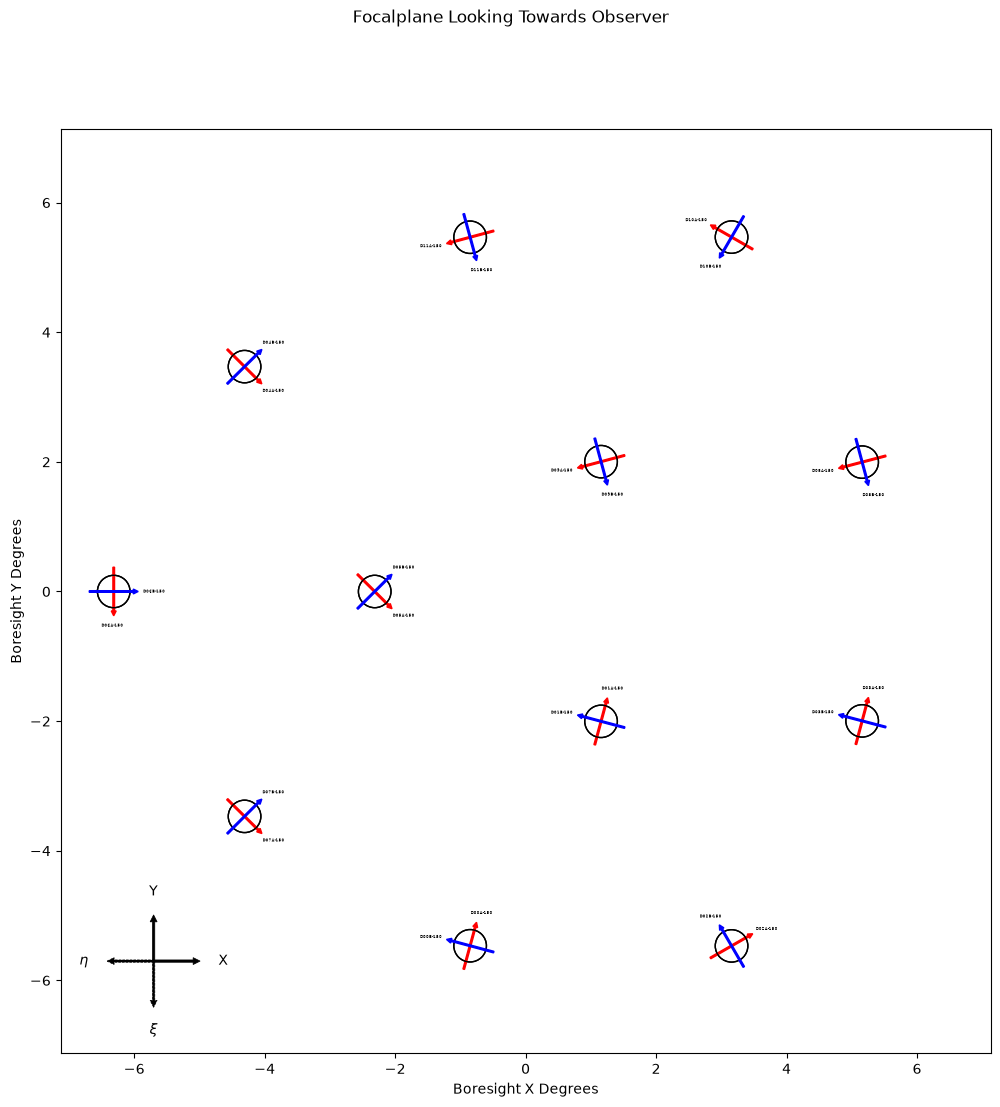

In [22]:
# Make a plot of this focalplane layout.
detpolcol = {
    x: "red" if re.match(r".*A-.*", x) is not None else "blue" for x in focalplane.detectors
}

if rank == 0:
    plot_focalplane(
        focalplane=focalplane,
        width=1.2 * fov,
        height=1.2 * fov,
        show_labels=True,
        pol_color=detpolcol
        )

We will ignore adding an atmosphere monitoring detector.

Finally we build our telescope with this updated focalplane and Site

In [24]:
telescope = toast.instrument.Telescope("telescope", focalplane=focalplane, site=site)

# Simulated Observing Schedule

Now that we have a telescope, we create an observing schedule.

In [25]:
schedule = None

if rank == 0:
    tdir = out_dir
    if tdir is None:
        tdir = tempfile.mkdtemp()

    sch_file = os.path.join(tdir, "ground_schedule.txt")
    toast.schedule_sim_ground.run_scheduler(
        opts=[
            "--site-name",
            telescope.site.name,
            "--telescope",
            telescope.name,
            "--site-lon",
            "{}".format(telescope.site.earthloc.lon.to_value(u.degree)),
            "--site-lat",
            "{}".format(telescope.site.earthloc.lat.to_value(u.degree)),
            "--site-alt",
            "{}".format(telescope.site.earthloc.height.to_value(u.meter)),
            "--patch",
            "bossn,1,-180,15,-140,2",
            "--start",
            "2025-02-21 00:00:00",
            "--stop",
            "2025-02-23 00:00:00",
            "--out",
            sch_file,
            "--equalize-time",
            "--patch-coord",
            "C",
            "--el-min",
            "40",
            "--el-max",
            "70",
            "--sun-el-max",
            "90",
            "--sun-avoidance-angle",
            "30",
            "--moon-avoidance-angle",
            "0",
            "--ces-max-time",
            "36000",
            "--fp-radius",
            "0",
            "--boresight-angle-step",
            "180",
            "--boresight-angle-time",
            "1440",
            "--time-step-s",
            "600",
            "--lock-az-range",
            "--elevations",
            "40,50,60,70",
        ]
    )
    schedule = toast.schedule.GroundSchedule()
    schedule.read(sch_file)
    if out_dir is None:
        shutil.rmtree(tdir)
if world is not None:
    schedule = world.bcast(schedule, root=0)

TOAST INFO: Adding patch "bossn"
TOAST INFO: Rectangular format
TOAST INFO: Creating 'out_sim_ground'


TOAST INFO: Loading schedule from out_sim_ground/ground_schedule.txt
TOAST INFO: Loaded 4 scans from out_sim_ground/ground_schedule.txt totaling 14.7 hours.


# Simulated Observing

Now we use this schedule to create some fake observing with our telescope. This will generate the data containers with boresight pointing, but the detector data is still zero.

In [26]:
# Start with an empty data container
data = toast.Data(comm)

In [27]:
# Populate observations according to the schedule and telescope.
sim_ground = toast.ops.SimGround(
    telescope=telescope,
    weather="atacama",
    detset_key="pixel",
    schedule=schedule,
    median_weather=True, # no longer random weather, but less chance of an outlier
)
sim_ground.apply(data)

In [28]:
# Print out the result.
data.info()

Data distributed over 1 processes in 1 groups

<Observation
  name = 'bossn-0-0'
  uid = '155265126'  group has 1 processes
  telescope = <Telescope 'telescope': uid = 1274491784, site = <GroundSite 'atacama' : uid = 39949029, lon = -67.7861111111111 deg, lat = -22.958333333333332 deg, alt = 5199.999999999725 m, weather = <SimWeather : 'atacama', year = 2025, month = 1, hour = 5, site UID = 39949029, realization = 0, median = True)>, focalplane = <Focalplane: 24 detectors, sample_rate = 10.0 Hz, FOV = 9.9 deg, detectors = [D00A-150 .. D11B-150]>>
  session = <Session 'bossn-0-0': uid = 1556607182, start = 2025-02-21 03:28:00+00:00, end = 2025-02-21 06:52:59.900000+00:00>
  scan_el = 40.0 deg
  scan_min_el = 0.6981317007977318 rad
  scan_max_el = 0.6981317007977318 rad
  scan_min_az = 0.7527248312891583 rad
  scan_max_az = 1.1727223995218548 rad
  123000 total samples (123000 local)
  shared:  <SharedDataManager
    times (column): shape=(np.int64(123000),), dtype=float64
    position (

# Simulated Detector Data

Now we will simulate several components of our detector data. Before doing that, we set up some operators that compute our detector pointing and response on the sky (the "pointing matrix"). In TOAST, the pointing matrix is split into the pixelization of detector samples and the Stokes weights (response to I/Q/U/V on the sky).

## Detector Pointing

There are 3 types of operators that define the detector pointing. The first is the geometric offset from the boresight coordinate frame to the detector coordinate frame. In the simplest case this is just a quaternion for each detector (stored in the focalplane table). Once the geometric detector pointing is computed, the pixelization on the sky is specified by a separate operator. Finally, the response of the detector to incoming Stokes parameters is given by another operator.

In [48]:
# Let's explore the focal plane table

print(focalplane.detectors[0])
print(data.obs[0].detdata['pointing'])

D00A-150


KeyError: 'pointing'

In [35]:
# Geometric detector pointing from boresight frame to detector frame.  We define these
# for both horizontal and equatorial coordinates, since we need the detector pointing
# in horizontal coordinates for atmosphere simulation below.

det_point_azel = toast.ops.PointingDetectorSimple(
    boresight=defaults.boresight_azel,
    quats="quats_azel"
)
print(det_point_azel)
det_point_radec = toast.ops.PointingDetectorSimple(
    boresight=defaults.boresight_radec,
    quats="quats_radec"
)

<PointingDetectorSimple
  API = 0 # Internal interface version for this operator
  boresight = boresight_azel # Observation shared key for boresight
  coord_in = None # The input boresight coordinate system ('C', 'E', 'G')
  coord_out = None # The output coordinate system ('C', 'E', 'G')
  det_mask = 1 # Bit mask value for per-detector flagging
  enabled = True # If True, this class instance is marked as enabled
  hwp_angle = hwp_angle # Observation shared key for HWP angle
  hwp_angle_offset = 0.0 deg # HWP angle offset to apply when constructing deflection
  hwp_deflection_radius = None # If non-zero, nominal detector pointing will be deflected in a circular pattern according to HWP phase.
  kernel_implementation = 0 # Which kernel implementation to use (DEFAULT, COMPILED, NUMPY, JAX).
  name = PointingDetectorSimple # The 'name' of this class instance
  quats = quats_azel # Observation detdata key for output quaternions
  shared_flag_mask = 1 # Bit mask value for optional flagging
 